In [1]:
from sklearn.datasets import make_regression
import matplotlib.pyplot as plt
import numpy as np

In [2]:
X, y = make_regression(n_samples=100, n_features=1,n_informative=1, n_targets=1, noise = 20, random_state=13)

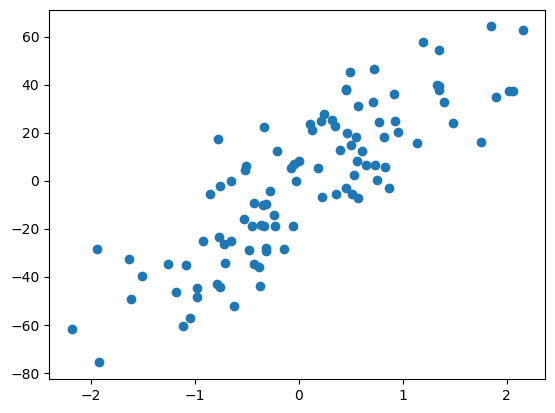

In [3]:
plt.scatter(X,y)

In [5]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X, y)
print(lr.coef_)
print(lr.intercept_)

[27.82809103]
-2.29474455867698


In [6]:
from sklearn.linear_model import Ridge

In [7]:
rr = Ridge(alpha=10)
rr.fit(X, y)
print(rr.coef_)
print(rr.intercept_)

[24.9546267]
-2.126913003523573


In [9]:
rr1 = Ridge(alpha=100)
rr1.fit(X, y)
print(rr1.coef_)
print(rr1.intercept_)

[12.93442104]
-1.4248441496033308


In [10]:
rr2 = Ridge(alpha=1000)
rr2.fit(X, y)
print(rr2.coef_)
print(rr2.intercept_)

[2.22362237]
-0.7992543425229544


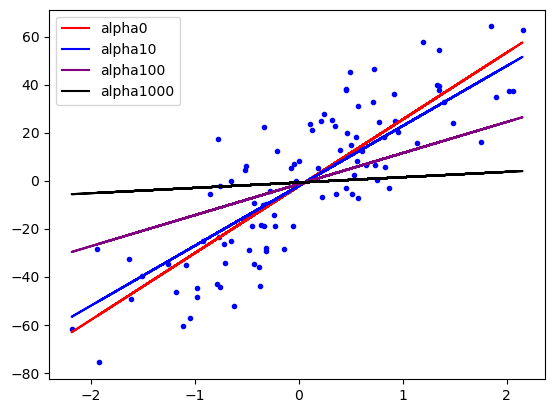

In [14]:
plt.plot(X,y,'b.')
plt.plot(X, lr.predict(X),  color='red', label='alpha0')
plt.plot(X, rr.predict(X), color='blue', label='alpha10')
plt.plot(X, rr1.predict(X), color='purple', label='alpha100')
plt.plot(X, rr2.predict(X), color='black', label='alpha1000')

plt.legend()
plt.show()

## from Scratch Ridge

In [41]:
class myRidge:
    def __init__(self, alpha = 10):
        self.alpha = alpha
        self.m = None
        self.b = None

    def fit(self, X_train, y_train):
        num = 0
        den = 0

        for i in range(X_train.shape[0]):
            num = num + (y_train[i] - y_train.mean())*(X_train[i] - X_train.mean())
            den = den + (X_train[i] - X_train.mean())*(X_train[i] - X_train.mean())

        den = den + self.alpha

        self.m = num / den
        self.b = y_train.mean() - (self.m*X_train.mean())

        print(self.m, self.b)

    def predict(self, X_test):
        return self.m*X_test + self.b

In [42]:
my_rr = myRidge(1000)
my_rr.fit(X, y)

[2.22362237] [-0.79925434]


In [44]:
y_pred = my_rr.predict(X)

In [46]:
from sklearn.metrics import r2_score, mean_squared_error
print("R2 : ", r2_score(y, y_pred))
print("RMSE : ", np.sqrt(mean_squared_error(y, y_pred)))

R2 :  0.10793829293061352
RMSE :  29.202216515508898
